# Построить прогноз на 8 месяцев методом сезонной декомпозиции

Общее описание данных

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics
Данные собирались ежемесячно с января 1994 по апрель 2003

Источник данных: http://www.choosechicago.com/.

Вариант 3 выполняют те, чья фамилия начинается с букв Л - С

Вариант 3:
Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения процента занятых номеров за один день. Усреднение по отелям и по дням месяца.
Данные расположены в столбце x3 файла Chicago_hotels.csv

In [49]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Процедура сезонной декомпозиции
from statsmodels.tsa.seasonal import seasonal_decompose

# Процедура обыкновенной линейной регрессии
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline

In [50]:
df = df = pd.read_csv('/content/data.csv', sep=';', decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.4+ KB


Оставляем только дату в формате "Месяц Год" и столбец x3

In [51]:
df3 = df[['date1', 'date2', 'x3']].copy()
df3['date'] = df3['date1'].str.strip() + ' ' + df3['date2'].astype(str)
df3 = df3[['date', 'x3']]
df3['date'] = pd.to_datetime(df3['date'])
df3.set_index('date', inplace=True)

# Проверка
df3.head()

/tmp/ipykernel_5844/2264257720.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df3['date'] = pd.to_datetime(df3['date'])


,x3
date,
1994-01-01,51.9
1994-02-01,60.1
1994-03-01,65.0
1994-04-01,69.8
1994-05-01,72.4


Для декомпозиции используем только ряд x3

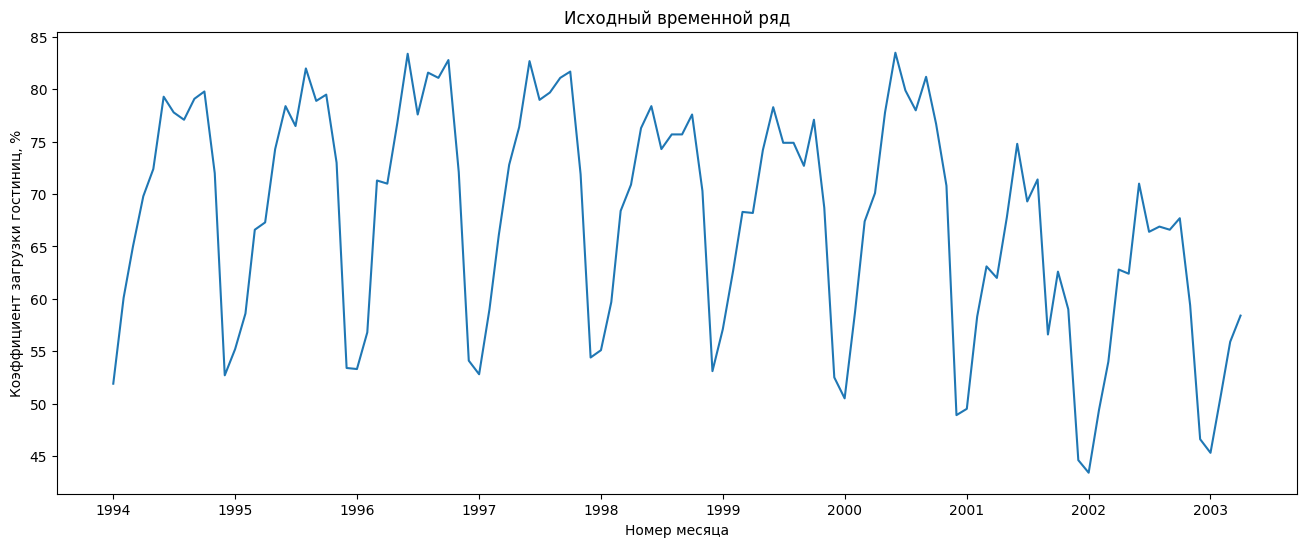

In [52]:
ts = df3['x3'].copy()

plt.figure(figsize=(16, 6))
plt.plot(ts)
plt.title('Исходный временной ряд')
plt.xlabel('Номер месяца')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.show()

В ряде наблюдается единичный выброс. Чтобы он не искажал оценку тренда и прогноз, выполним мягкое сглаживание по квантилям. Мы не удаляем наблюдение, а только ограничиваем экстремальные значения.

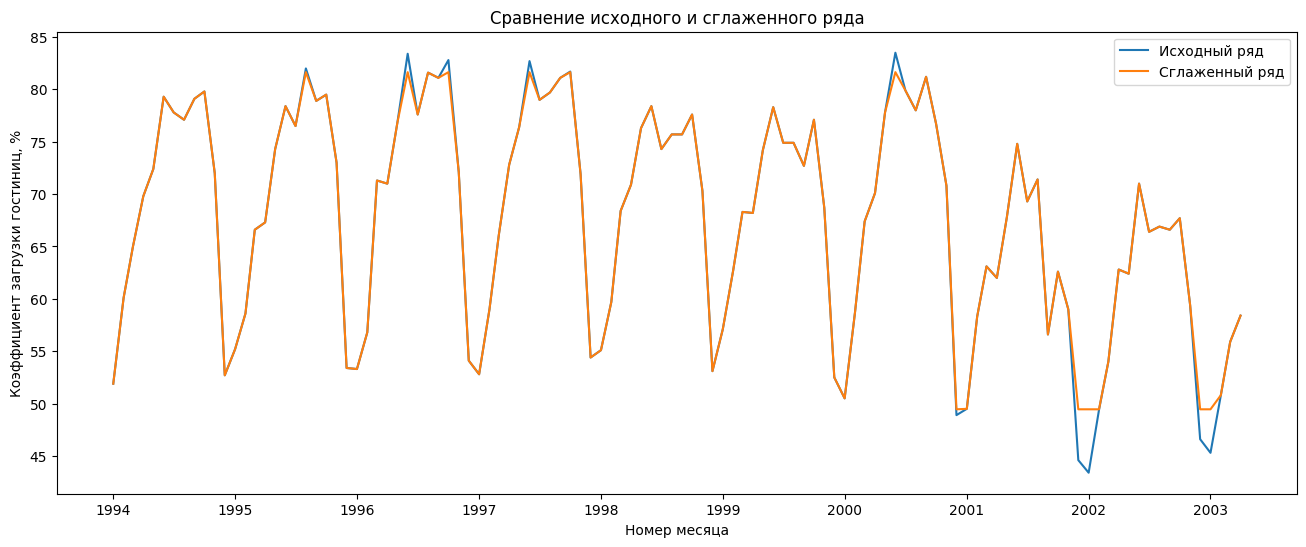

In [53]:
ts_clean = ts.clip(
    lower=ts.quantile(0.05),
    upper=ts.quantile(0.95)
)

plt.figure(figsize=(16, 6))
plt.plot(ts, label='Исходный ряд')
plt.plot(ts_clean, label='Сглаженный ряд')
plt.title('Сравнение исходного и сглаженного ряда')
plt.xlabel('Номер месяца')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.legend(loc='best')
plt.show()


Используем аддитивную модель, так как амплитуда сезонных колебаний остаётся примерно постоянной на протяжении всего периода. Период сезонности = 12, так как данные ежемесячные.


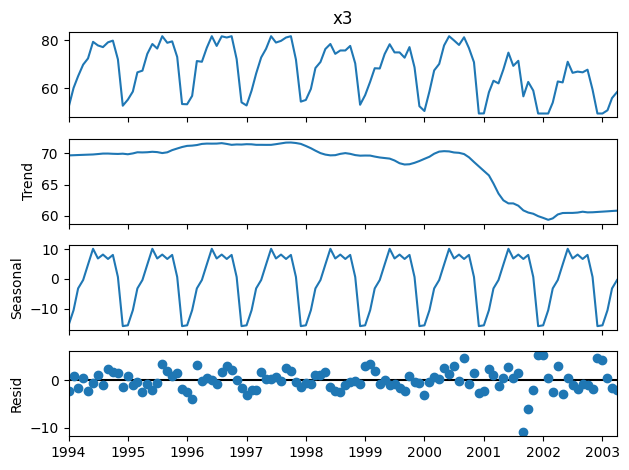

In [54]:
result = seasonal_decompose(
    ts_clean,
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

# График декомпозиции
result.plot()
plt.tight_layout()
plt.show()

В результате сезонной декомпозиции временной ряд был разложен на тренд, сезонную компоненту и случайную составляющую. Обнаружена выраженная сезонность с постоянной амплитудой, а также умеренный нисходящий тренд в конце периода. Остаточная компонента не содержит выраженной структуры и колеблется около нуля, что свидетельствует о корректности выбранной аддитивной модели.

Для аддитивной модели сезонную компоненту вычитаем

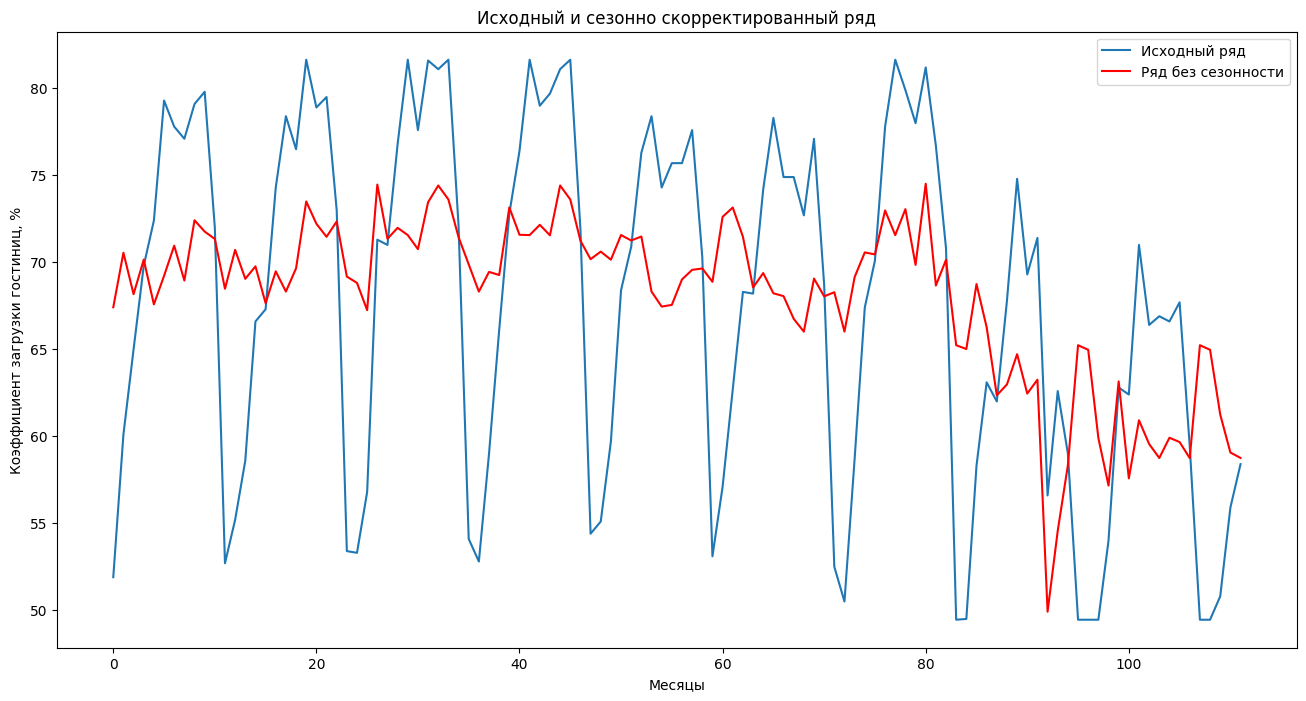

In [55]:
sa = ts_clean - result.seasonal

plt.figure(figsize=(16, 8))
plt.plot(ts_clean.values, label='Исходный ряд')
plt.plot(sa.values, label='Ряд без сезонности', color='red')
plt.legend(loc='best')
plt.xlabel('Месяцы')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.title('Исходный и сезонно скорректированный ряд')
plt.show()

Формируем номер месяца и полиномиальные признаки

In [56]:
trend_df = pd.DataFrame({
    'trend': result.trend,
    'month_num': np.arange(1, len(ts_clean) + 1)
})

trend_df['num2'] = trend_df['month_num'] ** 2
trend_df['num3'] = trend_df['month_num'] ** 3

# Целевая переменная — трендовая компонента
y = trend_df['trend']

# Наборы признаков для разных моделей тренда
X1 = trend_df[['month_num']]                    # линейный тренд
X2 = trend_df[['month_num', 'num2']]            # квадратичный тренд
X3 = trend_df[['month_num', 'num2', 'num3']]    # кубический тренд


In [57]:
# Линейная модель
model1 = LinearRegression()
model1.fit(X1, y)
y1 = model1.predict(X1)

coef1 = pd.DataFrame(
    list(zip(['intercept'] + X1.columns.tolist(), (model1.intercept_,) + tuple(model1.coef_))),
    columns=['predictor', 'coef']
)
print('Коэффициенты линейной модели:')
display(coef1)

# Квадратичная модель
model2 = LinearRegression()
model2.fit(X2, y)
y2 = model2.predict(X2)

coef2 = pd.DataFrame(
    list(zip(['intercept'] + X2.columns.tolist(), (model2.intercept_,) + tuple(model2.coef_))),
    columns=['predictor', 'coef']
)
print('Коэффициенты квадратичной модели:')
display(coef2)

# Кубическая модель
model3 = LinearRegression()
model3.fit(X3, y)
y3 = model3.predict(X3)

coef3 = pd.DataFrame(
    list(zip(['intercept'] + X3.columns.tolist(), (model3.intercept_,) + tuple(model3.coef_))),
    columns=['predictor', 'coef']
)
print('Коэффициенты кубической модели:')
display(coef3)

Коэффициенты линейной модели:


,predictor,coef
0,intercept,73.538455
1,month_num,-0.097581


Коэффициенты квадратичной модели:


,predictor,coef
0,intercept,68.639487
1,month_num,0.160259
2,num2,-0.002282


Коэффициенты кубической модели:


,predictor,coef
0,intercept,6.866556e+01
1,month_num,1.575504e-01
2,num2,-2.222112e-03
3,num3,-3.519868e-07


Сравниваем по R2 и RMSE

In [58]:
compare = pd.DataFrame({
    'model': ['Линейная', 'Квадратичная', 'Кубическая'],
    'R2': [
        r2_score(y, y1),
        r2_score(y, y2),
        r2_score(y, y3)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y, y1)),
        np.sqrt(mean_squared_error(y, y2)),
        np.sqrt(mean_squared_error(y, y3))
    ]
})

print('Сравнение моделей тренда:')
display(compare)


Сравнение моделей тренда:


,model,R2,RMSE
0,Линейная,0.606948,2.538785
1,Квадратичная,0.884389,1.376897
2,Кубическая,0.884394,1.376866


Визуально сравниваем, какая модель лучше описывает тренд

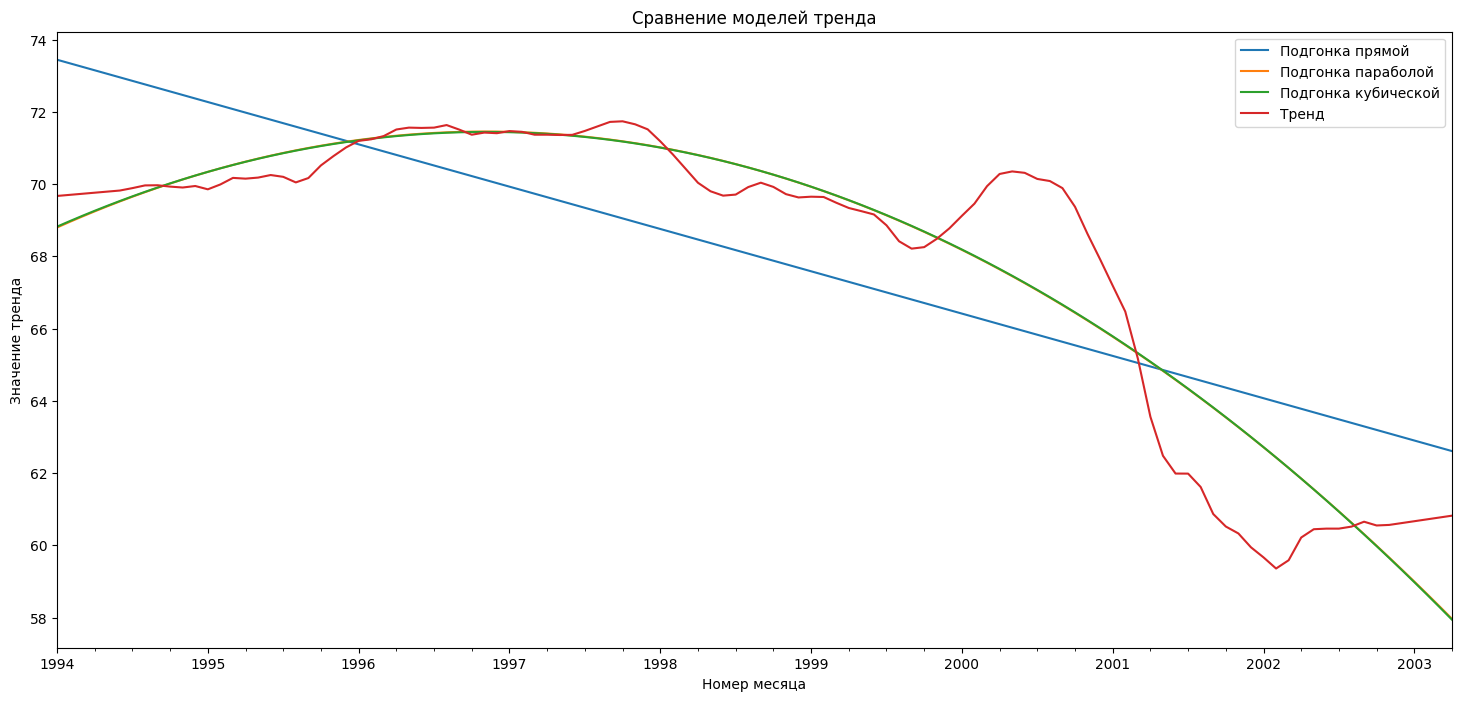

In [59]:
pred_trend = pd.DataFrame({
    'Подгонка прямой': y1,
    'Подгонка параболой': y2,
    'Подгонка кубической': y3,
    'Тренд': y
})

pred_trend.plot(figsize=(18, 8))
plt.title('Сравнение моделей тренда')
plt.xlabel('Номер месяца')
plt.ylabel('Значение тренда')
plt.show()


Для прогноза выбираем квадратичную модель. Она хорошо описывает тренд, но при этом проще и устойчивее, чем кубическая модель.


In [60]:
selected_model = model2

В исходном ряду 112 наблюдений. Прогноз строим на следующие 8 месяцев: 113–120

In [61]:
horizon = 8

X_forecast = pd.DataFrame({
    'month_num': np.arange(len(ts_clean) + 1, len(ts_clean) + horizon + 1)
})

X_forecast['num2'] = X_forecast['month_num'] ** 2

X_forecast

,month_num,num2
0,113,12769
1,114,12996
2,115,13225
3,116,13456
4,117,13689
5,118,13924
6,119,14161
7,120,14400


In [62]:
trend_forecast = selected_model.predict(X_forecast)

print('Прогноз тренда на 8 месяцев:')
print(trend_forecast)

Прогноз тренда на 8 месяцев:
[57.61279513 57.25509158 56.89282449 56.52599385 56.15459966 55.77864193
 55.39812064 55.01303581]


Последнее фактическое наблюдение — апрель 2003. Значит прогноз строится на: май, июнь, июль, август, сентябрь, октябрь, ноябрь, декабрь. Поэтому берём сезонные поправки именно для месяцев 5–12.

In [63]:
seasonal_pattern = result.seasonal.iloc[:12].to_numpy()
seasonal_future = seasonal_pattern[4:12]

# Для аддитивной модели сезонные поправки ПРИБАВЛЯЕМ
forecast1 = trend_forecast + seasonal_future

print('Итоговый прогноз на 8 месяцев:')
print(forecast1)

Итоговый прогноз на 8 месяцев:
[62.43102164 67.3361191  63.73748872 64.67447752 62.83882408 63.81221819
 56.05424774 39.23319206]


,Период,Прогноз x3
0,May 2003,62.431022
1,June 2003,67.336119
2,July 2003,63.737489
3,August 2003,64.674478
4,September 2003,62.838824
5,October 2003,63.812218
6,November 2003,56.054248
7,December 2003,39.233192


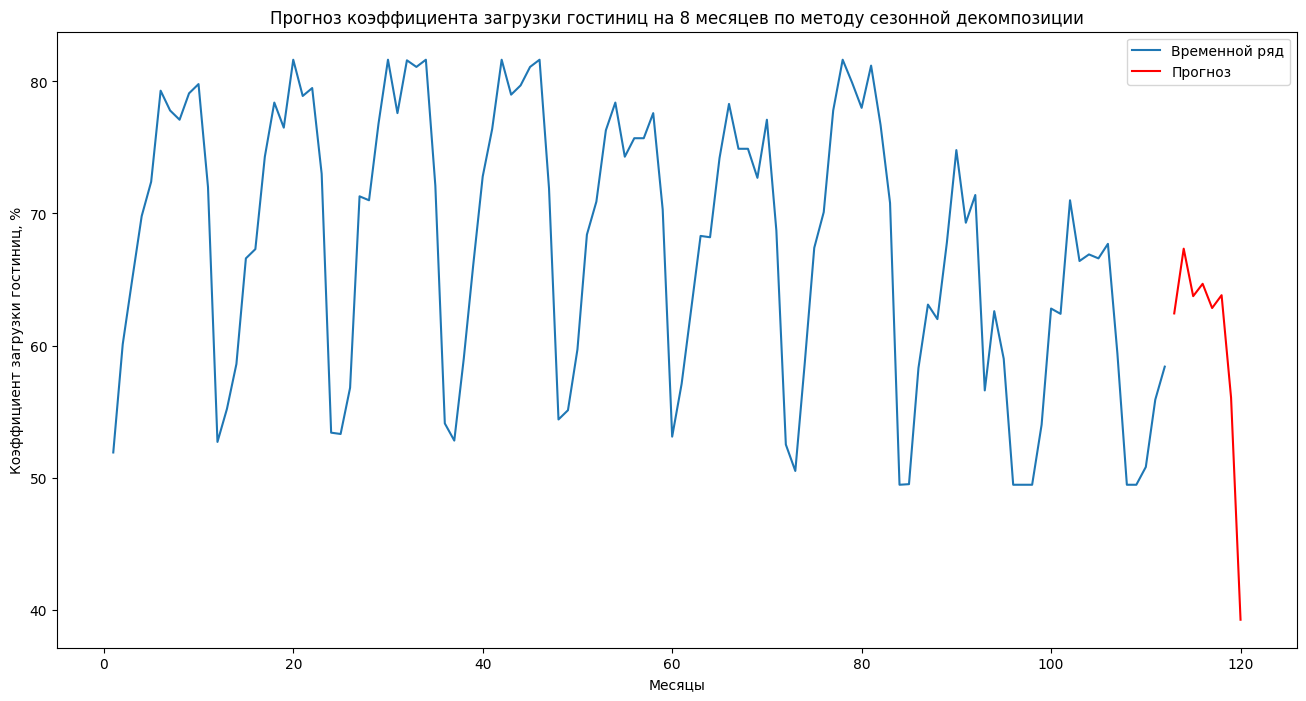

In [64]:
forecast_labels = [
    'May 2003',
    'June 2003',
    'July 2003',
    'August 2003',
    'September 2003',
    'October 2003',
    'November 2003',
    'December 2003'
]

forecast_result = pd.DataFrame({
    'Период': forecast_labels,
    'Прогноз x3': forecast
})

display(forecast_result)

plt.figure(figsize=(16, 8))

plt.plot(np.arange(1, len(ts_clean) + 1), ts_clean.values, label='Временной ряд')
plt.plot(
    np.arange(len(ts_clean) + 1, len(ts_clean) + horizon + 1),
    forecast,
    label='Прогноз',
    color='red'
)

plt.legend(loc='best')
plt.xlabel('Месяцы')
plt.ylabel('Коэффициент загрузки гостиниц, %')
plt.title('Прогноз коэффициента загрузки гостиниц на 8 месяцев по методу сезонной декомпозиции')
plt.show()

# Построить прогноз на 8 месяцев методом экспоненциального сглаживания

In [65]:
from statsmodels.tsa.api import ExponentialSmoothing

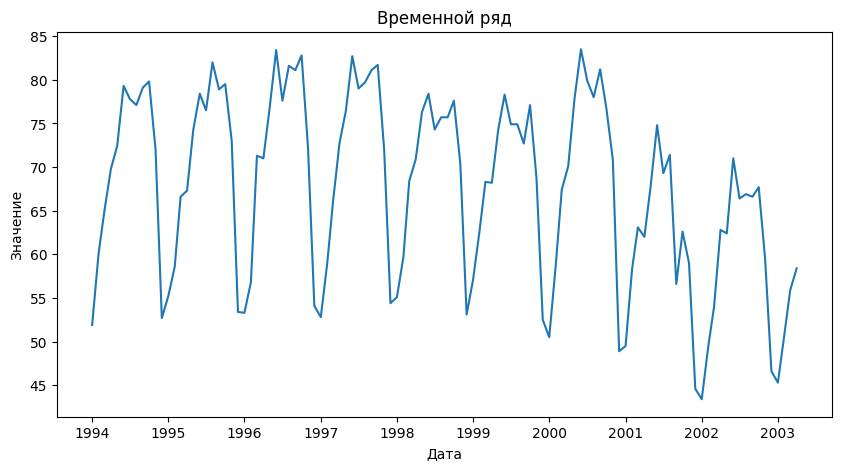

In [66]:
ts = df3['x3'].copy()

plt.figure(figsize=(10,5))
plt.plot(ts)
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.title("Временной ряд")
plt.show()

Строим модель для прогноза через экспоненциальное сглаживание. Берем аддитивный метод, период 12 (так как по месяцам), всегда trend='additive' по рекомендации Hyndman'а и trend='damped'

In [67]:
fit1 = ExponentialSmoothing(np.asarray(ts) ,seasonal_periods=12 ,trend='additive', seasonal='additive', damped_trend = True).fit()
len(ts)

112

In [68]:
fitted_ = fit1.predict(0, 121)
fitted_

array([52.33740424, 58.38917412, 66.76513061, 68.80049077, 74.48428692,
       79.32345131, 75.74585749, 78.33913266, 76.29673204, 79.3702217 ,
       72.19788655, 54.84072024, 54.04137249, 60.79425111, 66.96313065,
       69.62145792, 73.43103145, 79.73757567, 75.37026087, 77.38894074,
       78.37685447, 80.17006471, 72.35038654, 55.38559159, 54.61608112,
       60.00696871, 65.59446553, 71.43566238, 76.21044242, 82.33563994,
       79.21376703, 79.74821642, 79.24596042, 81.72319078, 74.81044814,
       56.0425326 , 55.27871202, 60.03656917, 66.76234142, 69.20906647,
       76.1102274 , 82.06545328, 78.70551972, 80.24434467, 78.46154035,
       81.34788988, 74.04355095, 55.5705075 , 55.21103481, 61.22106637,
       67.68489962, 70.85883157, 75.8711199 , 81.89669124, 76.33976756,
       76.63612999, 74.64261443, 76.68695081, 69.67827162, 52.6716387 ,
       53.15936567, 61.31925209, 69.32249029, 71.57233479, 74.77071206,
       80.26432564, 75.52007297, 76.56936894, 74.18561605, 74.87

In [69]:
fitted_series = pd.Series(
    fitted_,
    index=pd.date_range(
        start=ts.index[0],
        periods=len(fitted_),
        freq='MS'
    )
)

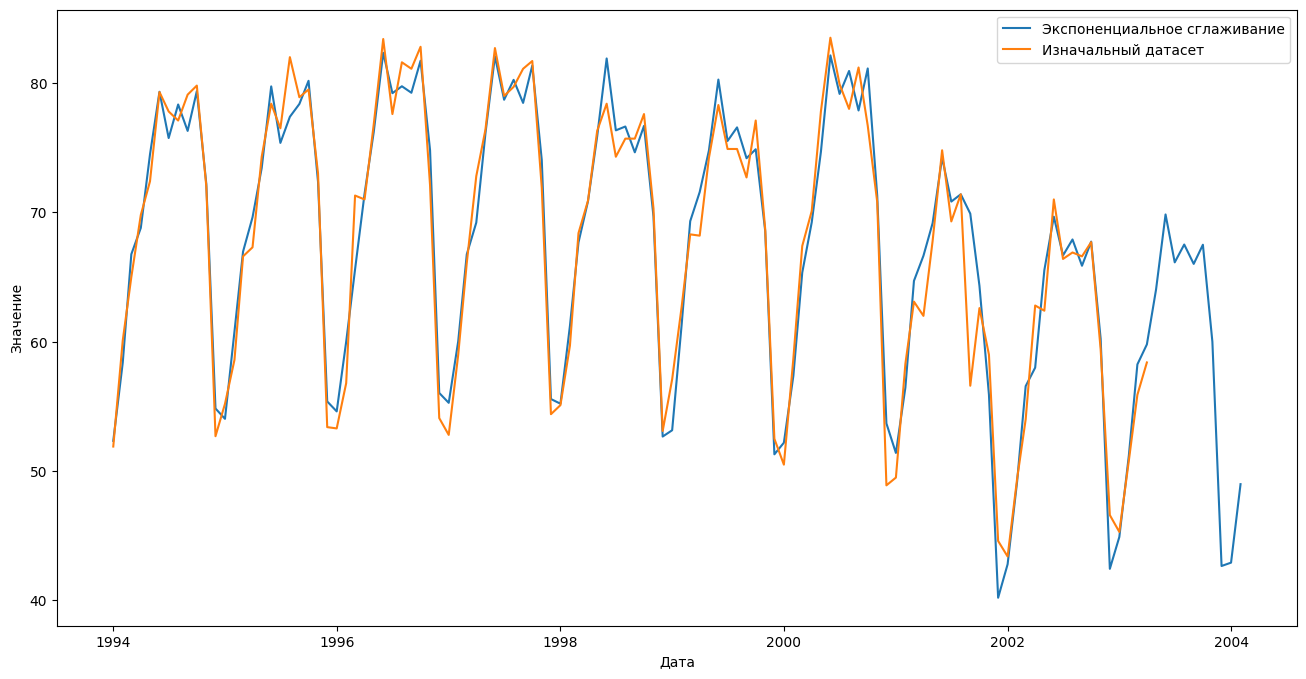

In [70]:
plt.figure(figsize=(16,8))
plt.plot(fitted_series, label='Экспоненциальное сглаживание')
plt.plot(ts, label='Изначальный датасет')
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend(loc='best')
plt.show()

Сам прогноз

In [71]:
forecast2 = fitted_[112:121]
forecast2

array([64.04237799, 69.83849939, 66.13684376, 67.51495332, 66.01725452,
       67.49892095, 60.00432216, 42.6665627 , 42.92593212])

# Построить прогноз на 8 месяцев методом ARIMA

In [80]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.6 MB/s eta 0:00:00


In [81]:
import pmdarima as pm

In [87]:
ts = df3['x3'].asfreq('MS')

In [88]:
model_arima = pm.auto_arima(
    ts,
    start_p=2, d=None, start_q=2,
    max_p=2, max_d=2, max_q=2,
    start_P=1, D=None, start_Q=1,
    max_P=2, max_D=2, max_Q=2, max_order=8,
    m=12,
    seasonal=True,
    stationary=False,
    information_criterion='aic',
    alpha=0.05,
    test='kpss', seasonal_test='ch',
    stepwise=True, n_jobs=1, start_params=None, trend='c',
    transparams=True,
    solver='newton',
    maxiter=50,
    disp=0, callback=None, offset_test_args=None,
    seasonal_test_args=None, suppress_warnings=False,
    error_action='warn',
    random_state=None, n_fits=10, return_valid_fits=False,
    out_of_sample_size=0, scoring='mse', scoring_args=None
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maxim

1. **`ConvergenceWarning: Maximum Likelihood optimization failed to converge`**  
   — при переборе некоторых комбинаций параметров оптимизация не сошлась. Это нормально для автоматического подбора: модель перебирает много кандидатов, и не все из них подходят под данные.

2. **`UserWarning: Non-invertible starting seasonal moving average`**  
   — начальные параметры для сезонного скользящего среднего были скорректированы алгоритмом.

In [85]:
model_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  112
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                -288.270
Date:                            Tue, 12 May 2026   AIC                            586.540
Time:                                    12:34:00   BIC                            600.088
Sample:                                01-01-1994   HQIC                           592.036
                                     - 04-01-2003                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0001      0.003     -0.045      0.964      -0.006       0.006
ma.L1         -0.4109      0.122     -3.366      0.001      -0.650      -0.172
ar.S.L12       0.9984      0.003    297.453      0.000       0.992       1.005
ma.S.L12      -0.8347      0.176     -4.752      0.000      -1.179      -0.490
sigma2         7.3332      0.670     10.951      0.000       6.021       8.646
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               214.12
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               2.09   Skew:                            -1.22
Prob(H) (two-sided):                  0.03   Kurtosis:                         9.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [89]:
model_arima.fit(ts)

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(1, 0, 1, 12), trend='c',
      with_intercept=False)

In [90]:
forecast3 = model_arima.predict(n_periods=8)
forecast3

,0
2003-05-01,63.443511
2003-06-01,69.335293
2003-07-01,65.386468
2003-08-01,66.430872
2003-09-01,64.300415
2003-10-01,65.786138
2003-11-01,58.553881
2003-12-01,41.869434


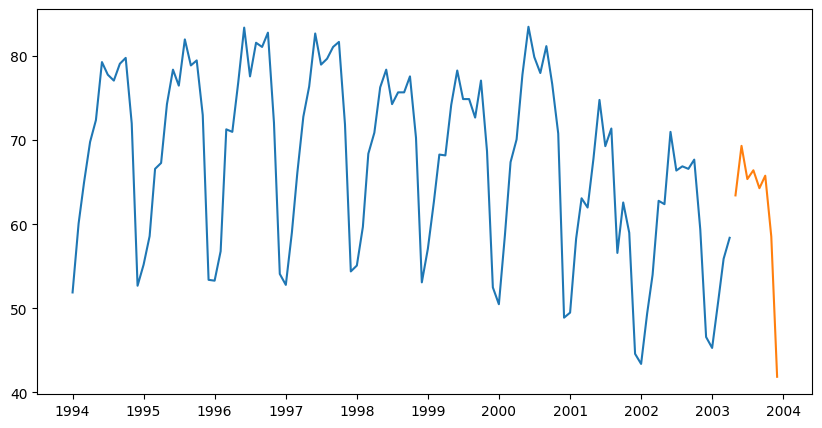

In [92]:
plt.figure(figsize=(10,5))
plt.plot(ts, label = 'Train')
plt.plot(forecast3, label = 'Prediction')
plt.show()

# Сравним прогнозы по трем методам